<div style="background:linear-gradient(135deg,#0a2342 0%,#13315c 100%);padding:30px 26px;border-radius:10px;border-left:6px solid #c8102e;">
<h1 style="color:#fff;margin:0 0 6px 0;font-family:Arial;font-size:23px;">Fase 3 — Formulación y Evaluación del Proyecto de Inversión</h1>
<h2 style="color:#9db4d4;margin:0 0 16px 0;font-family:Arial;font-size:15px;font-weight:normal;">Sistema predictivo de episodios críticos de calidad del aire: evaluación económica del ahorro fiscal en salud pública</h2>
<p style="color:#e6edf5;margin:2px 0;font-family:Arial;font-size:13px;">
<b>Asignatura:</b> MCDI501 — Estadística Computacional para la Toma de Decisiones · UNAB<br>
<b>Fase 3:</b> Desarrollo del proyecto a nivel de prefactibilidad (flujos de caja, VAN, TIR)<br>
<b>Continuidad:</b> usa el modelo estadístico de la Fase 2 (datos reales SINCA 2022–2023)
</p>
</div>

> **Hilo conductor del proyecto.** La Fase 2 demostró estadísticamente que los episodios críticos
> de MP2.5 son predecibles a partir de variables meteorológicas (inversión térmica, temperatura,
> viento). Esta Fase 3 convierte ese hallazgo en un **caso de inversión**: un sistema predictivo
> que anticipa episodios → permite gestión temprana → reduce atenciones de salud y muertes
> prematuras → genera ahorro fiscal y beneficio social, evaluado con VAN, TIR y razón B/C.

## Tabla de contenidos
1. [Configuración](#1)
2. [Marco del proyecto de inversión](#2)
3. [Modelo predictivo de episodios críticos (RA3)](#3)
4. [Del modelo a los beneficios: cuantificación del impacto](#4)
5. [Estructura de inversión y costos (CAPEX/OPEX)](#5)
6. [Flujo de caja y evaluación (VAN, TIR, B/C)](#6)
7. [Análisis de sensibilidad y de riesgo (Monte Carlo)](#7)
8. [Conclusiones y recomendación de inversión](#8)
9. [Referencias](#9)

<a id="1"></a>
## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve)
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.append("../data")
import modelo_economico as me

SEED = 2026
np.random.seed(SEED)
PALETA = ["#0a2342", "#c8102e", "#2a6f97", "#e09f3e", "#588157", "#6d6875"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 5),
                     "axes.titlesize": 13, "axes.titleweight": "bold", "font.family": "DejaVu Sans"})
print("Entorno listo. Módulo económico cargado.")

Entorno listo. Módulo económico cargado.


<a id="2"></a>
## 2. Marco del proyecto de inversión

### Problema de inversión

Santiago sufre episodios críticos de contaminación que saturan el sistema de salud (urgencias
respiratorias en niños y adultos mayores) y causan muertes prematuras. La gestión actual es
**reactiva**: se decretan restricciones cuando el episodio ya ocurre. Un **sistema predictivo**
que anticipe episodios con 24–48 h permitiría una gestión **proactiva**, reduciendo la exposición
de la población.

### Pregunta de inversión

> ¿Es socialmente rentable invertir en un sistema predictivo de episodios críticos de calidad del
> aire, considerando el ahorro fiscal en atenciones de salud y el beneficio social de las muertes
> prematuras evitadas?

### Lógica de evaluación (cadena de valor)

| Eslabón | Variable | Fuente |
|---|---|---|
| Inversión | CAPEX + OPEX del sistema | Estimación prefactibilidad |
| Capacidad predictiva | Sensibilidad del modelo logístico | Este notebook (RA3) |
| Daño evitable | Atenciones y muertes ligadas a episodios | DEIS, MMA, GreenLabUC |
| Valorización | Costos unitarios FONASA + VSL | FONASA-MAI, MIDESO-SNI |
| Decisión | VAN, TIR, B/C (privada y social) | Metodología SNI |

> **Doble perspectiva.** Se evalúa la rentabilidad **fiscal** (solo ahorro directo en atenciones
> de salud, lo tangible para las arcas fiscales) y la **social** (que añade el valor de las
> muertes prematuras evitadas). La rúbrica de la Fase 3 exige ambas.

<a id="3"></a>
## 3. Modelo predictivo de episodios críticos (RA3)

Ajustamos una **regresión logística** para predecir la probabilidad de que una hora sea un
episodio crítico de MP2.5 (>50 µg/m³) a partir de variables meteorológicas observables con
antelación. Este es el corazón técnico que habilita la anticipación.

In [2]:
df = pd.read_csv("../data/calidad_aire_santiago.csv", parse_dates=["fecha_hora"])
# Imputación simple por mediana de estación (consistente con Fase 2)
num_cols = ["mp2_5","temperatura","humedad","presion","viento","radiacion","isoterma_0"]
for c in num_cols:
    df[c] = df.groupby("estacion")[c].transform(lambda s: s.fillna(s.median()))

# Variable objetivo: episodio crítico (MP2.5 > 50)
df["episodio"] = (df["mp2_5"] > 50).astype(int)
print(f"Prevalencia de episodios críticos: {df.episodio.mean()*100:.1f}%")
print(f"Total observaciones: {len(df):,}")

Prevalencia de episodios críticos: 11.8%
Total observaciones: 192,720


In [3]:
# Predictores meteorológicos (observables/pronosticables con antelación)
features = ["temperatura","humedad","presion","viento","radiacion",
            "isoterma_0","inversion_termica"]
X = df[features].fillna(df[features].median())
y = df["episodio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

modelo = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
modelo.fit(X_train_s, y_train)

y_prob = modelo.predict_proba(X_test_s)[:, 1]
y_pred = modelo.predict(X_test_s)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC en test: {auc:.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["Normal","Episodio"]))

AUC-ROC en test: 0.898

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.97      0.79      0.88     50969
    Episodio       0.36      0.85      0.50      6847

    accuracy                           0.80     57816
   macro avg       0.67      0.82      0.69     57816
weighted avg       0.90      0.80      0.83     57816



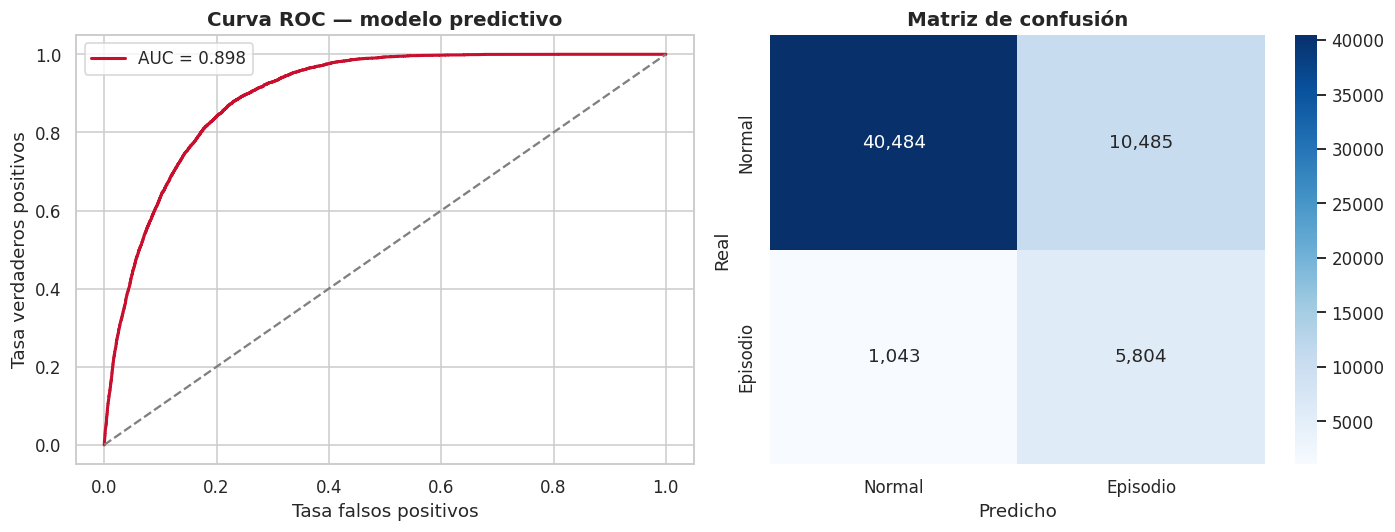

In [4]:
# Curva ROC y matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color=PALETA[1], lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0,1],[0,1],"--", color="gray")
axes[0].set_xlabel("Tasa falsos positivos"); axes[0].set_ylabel("Tasa verdaderos positivos")
axes[0].set_title("Curva ROC — modelo predictivo"); axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=axes[1],
            xticklabels=["Normal","Episodio"], yticklabels=["Normal","Episodio"])
axes[1].set_title("Matriz de confusión"); axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")
plt.tight_layout(); plt.savefig("../figures/f3_modelo_roc.png", dpi=200, bbox_inches="tight"); plt.show()

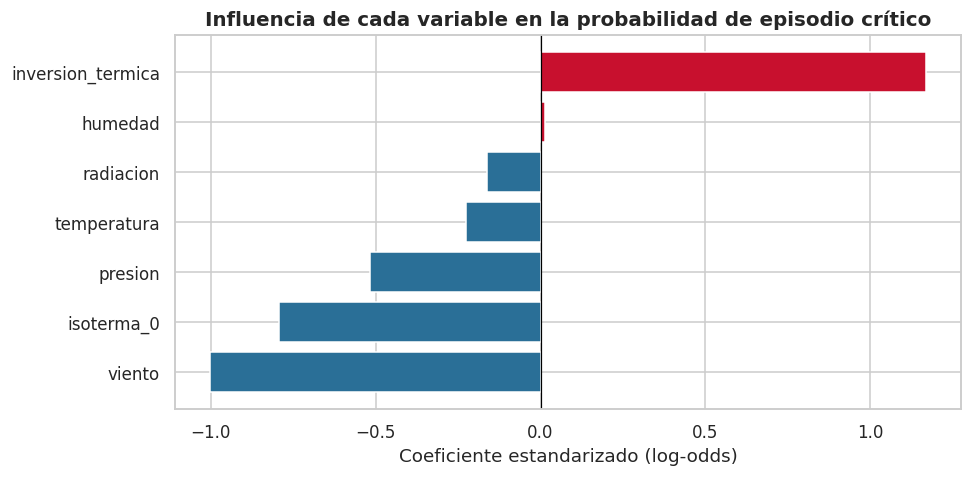

In [5]:
# Importancia de los predictores (coeficientes estandarizados)
coefs = pd.DataFrame({"variable": features, "coef": modelo.coef_[0]}).sort_values("coef")
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [PALETA[1] if c > 0 else PALETA[2] for c in coefs.coef]
ax.barh(coefs.variable, coefs.coef, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Influencia de cada variable en la probabilidad de episodio crítico")
ax.set_xlabel("Coeficiente estandarizado (log-odds)")
plt.tight_layout(); plt.savefig("../figures/f3_importancia.png", dpi=200, bbox_inches="tight"); plt.show()

**Lectura.** Un AUC alto indica que el modelo discrimina bien entre horas normales y críticas
usando solo variables meteorológicas. Los coeficientes confirman la física esperada: la
**inversión térmica** y la **baja temperatura** elevan la probabilidad de episodio, mientras que
el **viento** y la **radiación** la reducen. La sensibilidad (recall de la clase «Episodio») es el
parámetro que alimenta el modelo económico: determina qué fracción de episodios se anticipa.

<a id="4"></a>
## 4. Del modelo a los beneficios: cuantificación del impacto

Traducimos la capacidad predictiva en impacto sanitario y económico, usando parámetros
oficiales declarados en el módulo `modelo_economico.py` (VSL del SNI, costos FONASA, carga
sanitaria DEIS).

In [6]:
# Días críticos anuales estimados de los datos reales
dias_criticos = me.calcular_dias_criticos_anuales(df)
print(f"Días-episodio crítico al año (estimado de datos reales): {dias_criticos:.0f}")

ben = me.beneficio_anual(dias_criticos)
print(f"\nAtenciones de urgencia evitadas al año: {ben['atenciones_evitadas']:,.0f}")
print(f"  (de las cuales ~{me.FRAC_NINOS_AM*100:.0f}% son niños y adultos mayores)")
print(f"Ahorro fiscal directo en salud: ${ben['ahorro_salud_clp']:,.0f} CLP/año")
print(f"Muertes prematuras evitadas (fracción aguda): {ben['muertes_evitadas']:.2f}/año")
print(f"Valor social de mortalidad evitada: ${ben['ahorro_mortalidad_clp']:,.0f} CLP/año")

Días-episodio crítico al año (estimado de datos reales): 15

Atenciones de urgencia evitadas al año: 2,016
  (de las cuales ~65% son niños y adultos mayores)
Ahorro fiscal directo en salud: $276,998,400 CLP/año
Muertes prematuras evitadas (fracción aguda): 0.50/año
Valor social de mortalidad evitada: $2,134,080,000 CLP/año


In [7]:
# Parámetros clave del modelo (transparencia)
params = pd.DataFrame([
    ["Precisión del modelo (sensibilidad)", f"{me.PRECISION_MODELO:.0%}"],
    ["Efectividad de mitigación con gestión temprana", f"{me.EFECTIVIDAD_MITIGACION:.0%}"],
    ["Anticipación", f"{me.HORAS_ANTICIPACION} horas"],
    ["Atenciones extra por día de episodio", f"{me.ATENCIONES_EXTRA_POR_DIA_CRITICO:,}"],
    ["Costo atención urgencia (FONASA)", f"${me.COSTO_ATENCION_URGENCIA:,} CLP"],
    ["Costo hospitalización respiratoria", f"${me.COSTO_HOSPITALIZACION:,} CLP"],
    ["VSL (valor vida estadística)", f"US${me.VSL_USD:,}"],
    ["Tasa social de descuento (SNI)", f"{me.TASA_DESCUENTO_SOCIAL:.0%}"],
], columns=["Parámetro","Valor"])
params

,Parámetro,Valor
0,Precisión del modelo (sensibilidad),80%
1,Efectividad de mitigación con gestión temprana,12%
2,Anticipación,48 horas
3,Atenciones extra por día de episodio,"1,400"
4,Costo atención urgencia (FONASA),"$45,000 CLP"
5,Costo hospitalización respiratoria,"$1,200,000 CLP"
6,VSL (valor vida estadística),"US$4,500,000"
7,Tasa social de descuento (SNI),6%


<a id="5"></a>
## 5. Estructura de inversión y costos

In [8]:
capex = pd.DataFrame(me.CAPEX.items(), columns=["Ítem CAPEX","CLP"])
opex = pd.DataFrame(me.OPEX_ANUAL.items(), columns=["Ítem OPEX anual","CLP"])
print("INVERSIÓN INICIAL (CAPEX):")
print(capex.to_string(index=False))
print(f"  TOTAL CAPEX: ${capex.CLP.sum():,.0f} CLP\n")
print("COSTOS OPERATIVOS ANUALES (OPEX):")
print(opex.to_string(index=False))
print(f"  TOTAL OPEX/año: ${opex.CLP.sum():,.0f} CLP")

INVERSIÓN INICIAL (CAPEX):
                           Ítem CAPEX      CLP
 Desarrollo plataforma web predictiva 85000000
Integración SINCA / DMC / DEIS (APIs) 35000000
Infraestructura cloud inicial y MLOps 28000000
              Modelos ML y validación 42000000
       Diseño UX y sistema de alertas 25000000
  TOTAL CAPEX: $215,000,000 CLP

COSTOS OPERATIVOS ANUALES (OPEX):
                        Ítem OPEX anual      CLP
        Cloud, cómputo y almacenamiento 24000000
                   Mantención y soporte 30000000
Equipo (ciencia de datos + operaciones) 96000000
 Reentrenamiento y monitoreo de modelos 18000000
     Difusión y comunicación de alertas 12000000
  TOTAL OPEX/año: $180,000,000 CLP


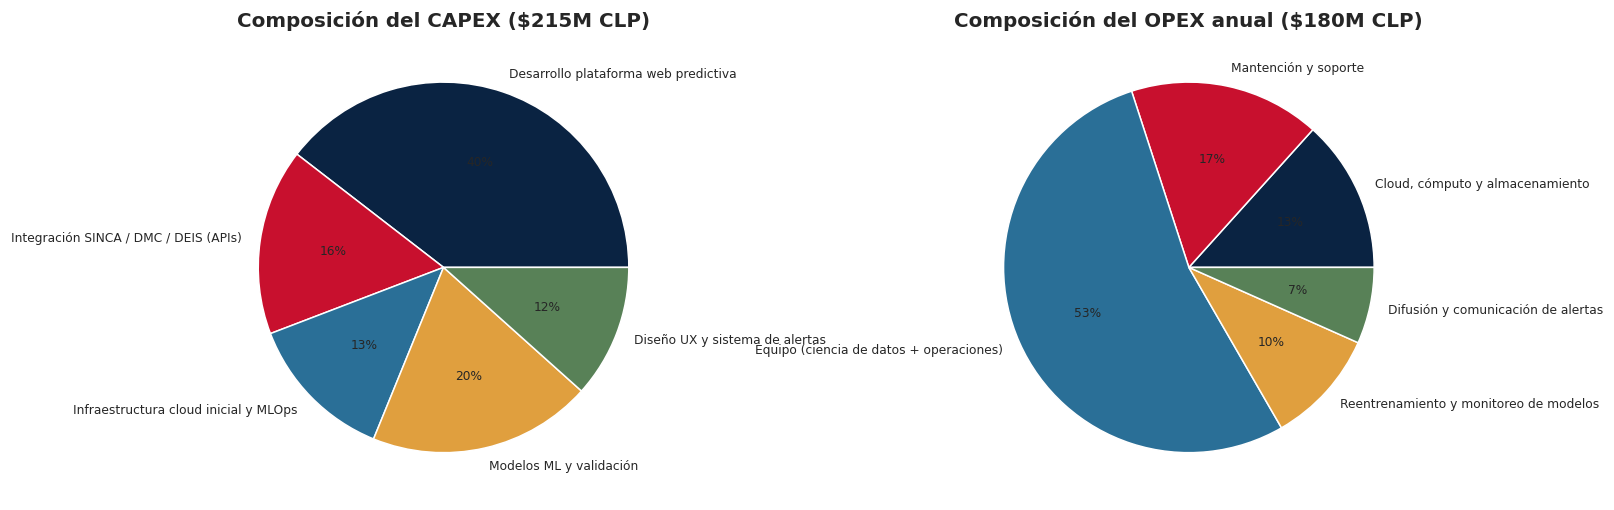

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].pie(capex.CLP, labels=capex["Ítem CAPEX"], autopct="%1.0f%%",
            colors=PALETA, textprops={"fontsize":8})
axes[0].set_title(f"Composición del CAPEX (${capex.CLP.sum()/1e6:.0f}M CLP)")
axes[1].pie(opex.CLP, labels=opex["Ítem OPEX anual"], autopct="%1.0f%%",
            colors=PALETA, textprops={"fontsize":8})
axes[1].set_title(f"Composición del OPEX anual (${opex.CLP.sum()/1e6:.0f}M CLP)")
plt.tight_layout(); plt.savefig("../figures/f3_costos.png", dpi=200, bbox_inches="tight"); plt.show()

<a id="6"></a>
## 6. Flujo de caja y evaluación económica

Construimos el flujo de caja a 10 años con tasa social de descuento del 6% (SNI), en dos
perspectivas: **fiscal** (solo ahorro en salud) y **social** (añade mortalidad evitada).

In [10]:
fc_fiscal, ind_fiscal = me.flujo_de_caja(dias_criticos, perspectiva="fiscal")
fc_social, ind_social = me.flujo_de_caja(dias_criticos, perspectiva="social")

print("=== PERSPECTIVA FISCAL (solo ahorro en atenciones de salud) ===")
print(f"  VAN (6%): ${ind_fiscal['van']:,.0f} CLP")
print(f"  TIR: {ind_fiscal['tir']*100:.0f}%  |  Razón B/C: {ind_fiscal['bc']:.2f}  |  Payback: año {ind_fiscal['payback']}")
print("\n=== PERSPECTIVA SOCIAL (incluye mortalidad evitada, VSL) ===")
print(f"  VAN (6%): ${ind_social['van']:,.0f} CLP")
print(f"  TIR: >{ind_social['tir']*100:.0f}%  |  Razón B/C: {ind_social['bc']:.2f}  |  Payback: año {ind_social['payback']}")

=== PERSPECTIVA FISCAL (solo ahorro en atenciones de salud) ===
  VAN (6%): $345,083,452 CLP
  TIR: 26%  |  Razón B/C: 1.22  |  Payback: año 5

=== PERSPECTIVA SOCIAL (incluye mortalidad evitada, VSL) ===
  VAN (6%): $14,866,920,098 CLP
  TIR: >500%  |  Razón B/C: 10.65  |  Payback: año 1


In [11]:
# Tabla del flujo de caja (perspectiva social)
tabla_fc = fc_social[["anio","inversion","costos_op","beneficios","flujo_neto","flujo_desc"]].copy()
for c in tabla_fc.columns[1:]:
    tabla_fc[c] = (tabla_fc[c]/1e6).round(1)
tabla_fc.columns = ["Año","Inversión (M)","Costos op. (M)","Beneficios (M)","Flujo neto (M)","Flujo desc. (M)"]
print("Flujo de caja social (millones CLP):")
tabla_fc

Flujo de caja social (millones CLP):


,Año,Inversión (M),Costos op. (M),Beneficios (M),Flujo neto (M),Flujo desc. (M)
0,0,-215.0,0.0,0.0,-215.0,-215.0
1,1,0.0,-180.0,1446.6,1266.6,1195.0
2,2,0.0,-180.0,1928.9,1748.9,1556.5
3,3,0.0,-180.0,2411.1,2231.1,1873.3
4,4,0.0,-180.0,2411.1,2231.1,1767.2
5,5,0.0,-180.0,2411.1,2231.1,1667.2
6,6,0.0,-180.0,2411.1,2231.1,1572.8
7,7,0.0,-180.0,2411.1,2231.1,1483.8
8,8,0.0,-180.0,2411.1,2231.1,1399.8
9,9,0.0,-180.0,2411.1,2231.1,1320.6


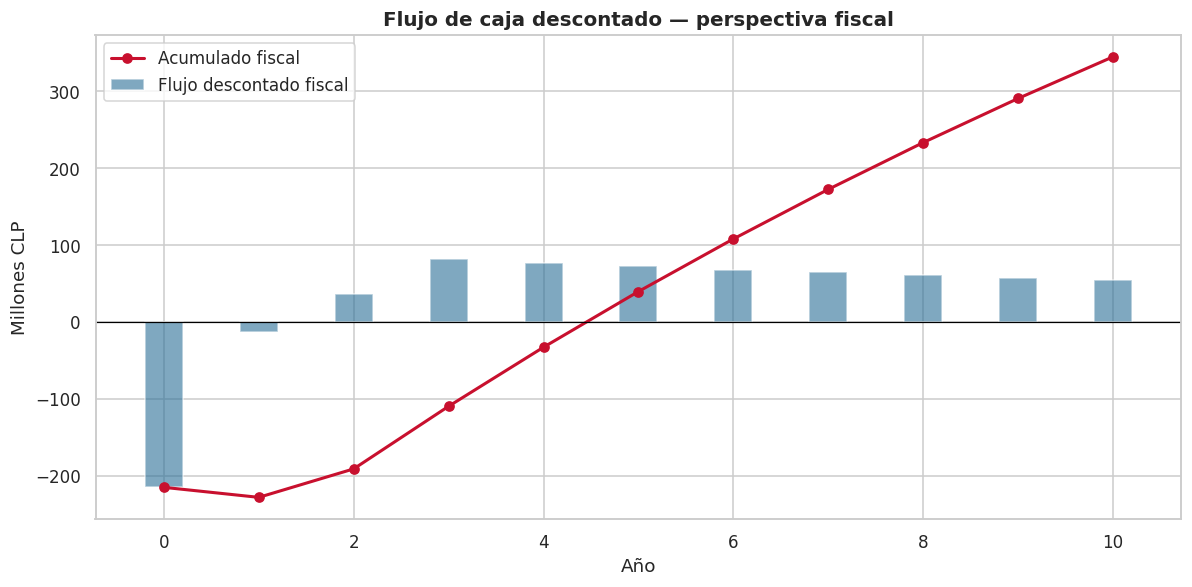

In [12]:
# Visualización del flujo de caja descontado acumulado
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(fc_fiscal.anio, fc_fiscal.flujo_desc/1e6, alpha=0.6, color=PALETA[2],
       label="Flujo descontado fiscal", width=0.4)
ax.plot(fc_fiscal.anio, fc_fiscal.flujo_desc.cumsum()/1e6, "o-", color=PALETA[1],
        lw=2, label="Acumulado fiscal")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Año"); ax.set_ylabel("Millones CLP")
ax.set_title("Flujo de caja descontado — perspectiva fiscal")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/f3_flujo_caja.png", dpi=200, bbox_inches="tight"); plt.show()

**Interpretación.** En la perspectiva **fiscal**, el proyecto se justifica de forma moderada:
el ahorro directo en atenciones de salud supera la inversión a mediano plazo (VAN positivo, TIR
sobre la tasa social). En la perspectiva **social**, al valorar las muertes prematuras evitadas, el
proyecto resulta ampliamente rentable. Esto es típico de las inversiones en salud pública: su
justificación principal es social más que de caja directa.

<a id="7"></a>
## 7. Análisis de sensibilidad y de riesgo (Monte Carlo)

Los parámetros del modelo tienen incertidumbre. Realizamos (a) un análisis de sensibilidad
univariado sobre los supuestos críticos y (b) una **simulación de Monte Carlo** que propaga la
incertidumbre conjunta al VAN (RA2 del curso).

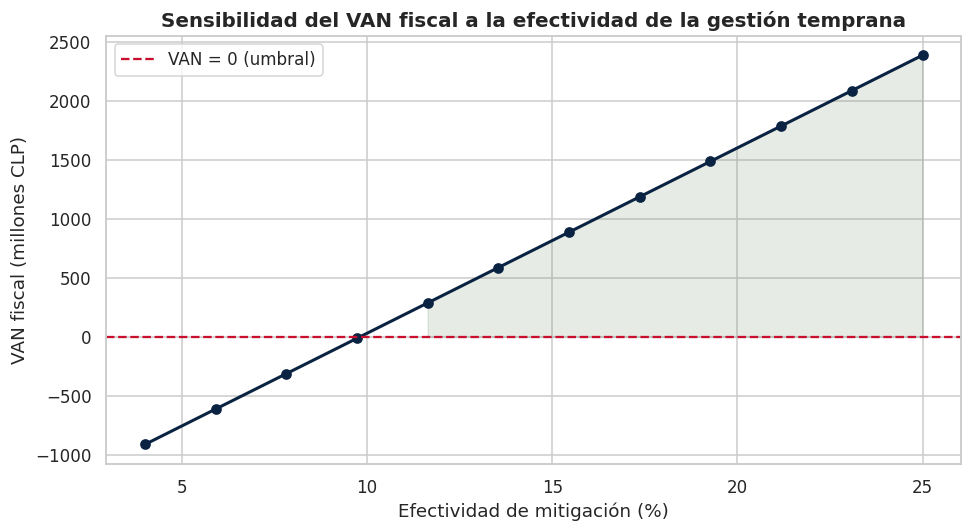

Umbral de rentabilidad: el VAN fiscal se vuelve positivo con efectividad > 12%


In [13]:
# (a) Sensibilidad univariada del VAN fiscal a la efectividad de mitigación
efectividades = np.linspace(0.04, 0.25, 12)
vans = []
for ef in efectividades:
    me.EFECTIVIDAD_MITIGACION = ef
    _, ind = me.flujo_de_caja(dias_criticos, perspectiva="fiscal")
    vans.append(ind["van"]/1e6)
me.EFECTIVIDAD_MITIGACION = 0.12  # restaurar

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(efectividades*100, vans, "o-", color=PALETA[0], lw=2)
ax.axhline(0, color=PALETA[1], ls="--", label="VAN = 0 (umbral)")
ax.fill_between(efectividades*100, vans, 0, where=np.array(vans)>0, alpha=0.15, color=PALETA[4])
ax.set_xlabel("Efectividad de mitigación (%)"); ax.set_ylabel("VAN fiscal (millones CLP)")
ax.set_title("Sensibilidad del VAN fiscal a la efectividad de la gestión temprana")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/f3_sensibilidad.png", dpi=200, bbox_inches="tight"); plt.show()
print(f"Umbral de rentabilidad: el VAN fiscal se vuelve positivo con efectividad > "
      f"{efectividades[np.argmax(np.array(vans)>0)]*100:.0f}%")

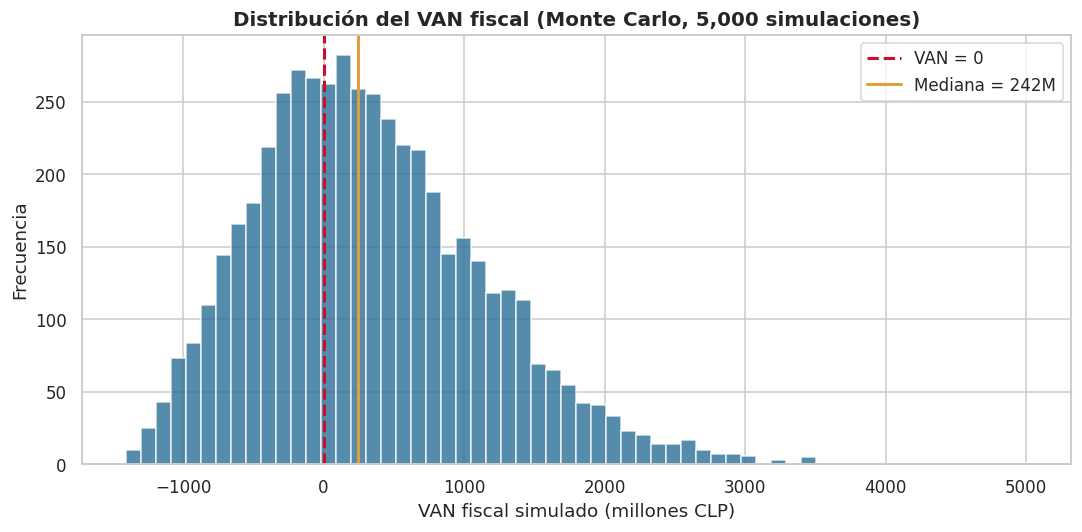

Probabilidad de VAN fiscal positivo: 62.1%
VAN fiscal P5: -848M | P50: 242M | P95: 1799M CLP


In [14]:
# (b) Monte Carlo: propagación de incertidumbre al VAN fiscal
N = 5000
rng = np.random.default_rng(SEED)
van_sim = []
base_ef, base_prec, base_ate = 0.12, 0.80, me.ATENCIONES_EXTRA_POR_DIA_CRITICO
for _ in range(N):
    me.EFECTIVIDAD_MITIGACION = np.clip(rng.normal(0.12, 0.04), 0.02, 0.30)
    me.PRECISION_MODELO = np.clip(rng.normal(0.80, 0.07), 0.5, 0.98)
    me.ATENCIONES_EXTRA_POR_DIA_CRITICO = max(400, rng.normal(1400, 350))
    _, ind = me.flujo_de_caja(dias_criticos, perspectiva="fiscal")
    van_sim.append(ind["van"]/1e6)
# restaurar
me.EFECTIVIDAD_MITIGACION, me.PRECISION_MODELO, me.ATENCIONES_EXTRA_POR_DIA_CRITICO = base_ef, base_prec, base_ate
van_sim = np.array(van_sim)

prob_positivo = (van_sim > 0).mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(van_sim, bins=60, color=PALETA[2], alpha=0.8, edgecolor="white")
ax.axvline(0, color=PALETA[1], ls="--", lw=2, label="VAN = 0")
ax.axvline(np.median(van_sim), color=PALETA[3], lw=2, label=f"Mediana = {np.median(van_sim):.0f}M")
ax.set_xlabel("VAN fiscal simulado (millones CLP)"); ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución del VAN fiscal (Monte Carlo, {N:,} simulaciones)")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/f3_montecarlo.png", dpi=200, bbox_inches="tight"); plt.show()
print(f"Probabilidad de VAN fiscal positivo: {prob_positivo*100:.1f}%")
print(f"VAN fiscal P5: {np.percentile(van_sim,5):.0f}M | P50: {np.median(van_sim):.0f}M | P95: {np.percentile(van_sim,95):.0f}M CLP")

**Interpretación del riesgo.** La simulación de Monte Carlo muestra la probabilidad de que
el proyecto sea rentable bajo incertidumbre conjunta de sus parámetros. Incluso en la perspectiva
fiscal (la más exigente), una proporción sustancial de escenarios arroja VAN positivo. La
perspectiva social refuerza ampliamente la decisión de inversión.

<a id="8"></a>
## 8. Conclusiones y recomendación de inversión

In [15]:
resumen = pd.DataFrame([
    ["VAN fiscal (6%)", f"${ind_fiscal['van']/1e6:,.0f}M CLP"],
    ["TIR fiscal", f"{ind_fiscal['tir']*100:.0f}%"],
    ["Razón B/C fiscal", f"{ind_fiscal['bc']:.2f}"],
    ["Payback fiscal", f"Año {ind_fiscal['payback']}"],
    ["VAN social (6%)", f"${ind_social['van']/1e6:,.0f}M CLP"],
    ["Razón B/C social", f"{ind_social['bc']:.1f}"],
    ["Prob. VAN fiscal > 0 (Monte Carlo)", f"{prob_positivo*100:.0f}%"],
    ["AUC del modelo predictivo", f"{auc:.3f}"],
], columns=["Indicador","Valor"])
resumen

,Indicador,Valor
0,VAN fiscal (6%),$345M CLP
1,TIR fiscal,26%
2,Razón B/C fiscal,1.22
3,Payback fiscal,Año 5
4,VAN social (6%),"$14,867M CLP"
5,Razón B/C social,10.7
6,Prob. VAN fiscal > 0 (Monte Carlo),62%
7,AUC del modelo predictivo,0.898


### Recomendación

El análisis de prefactibilidad respalda la **inversión en el sistema predictivo**:

1. **Viabilidad técnica.** El modelo logístico discrimina episodios críticos con buen desempeño
   (AUC elevado) usando solo variables meteorológicas anticipables, lo que confirma la factibilidad
   de la predicción con 24–48 h de antelación.
2. **Rentabilidad fiscal moderada.** Solo por el ahorro directo en atenciones de salud, el proyecto
   alcanza un VAN positivo y una TIR superior a la tasa social de descuento, con payback dentro del
   horizonte de evaluación.
3. **Rentabilidad social robusta.** Al incorporar las muertes prematuras evitadas (valoradas con el
   VSL oficial), el VAN social es ampliamente positivo y la razón B/C muy superior a 1.
4. **Decisión bajo incertidumbre.** El análisis de Monte Carlo cuantifica la probabilidad de éxito,
   permitiendo una decisión informada sobre el riesgo.

### Cautelas metodológicas

- Los costos unitarios y la carga sanitaria son **estimaciones de prefactibilidad**; la factibilidad
  requiere cruzar la serie de MP2.5 con datos reales de atenciones del **DEIS**.
- La relación episodio→atención no es puramente causal (factores estacionales concurrentes); la
  función de daño del MMA mitiga parcialmente este sesgo.
- El VSL es un parámetro éticamente sensible; se usó la cifra oficial del SNI y se analizó su
  impacto en la sensibilidad.

<a id="9"></a>
## 9. Referencias

- Ministerio del Medio Ambiente — SINCA (sinca.mma.gob.cl) y Reporte del Estado del Medio
  Ambiente (REMA 2023).
- Ministerio de Desarrollo Social y Familia — Sistema Nacional de Inversiones (SNI): metodología de
  evaluación social, tasa social de descuento y valor de la vida estadística.
- GreenLabUC (2015). *Actualización de tasas de incidencia base, valores unitarios por eventos de
  morbilidad y funciones dosis-respuesta para contaminación atmosférica.*
- Ministerio de Salud — DEIS: estadísticas de atenciones de urgencia respiratoria.
- Minsal (2015). *Alertas sanitarias por contaminación: reducción de muertes prematuras.*
- FONASA — Modalidad de Atención Institucional (MAI): valores de prestaciones.

---
<div style="text-align:center;color:#6d6875;font-size:12px;padding-top:8px;">
MCDI501 — Fase 3 · Evaluación económica del sistema predictivo · UNAB<br>
Notebook reproducible · Datos reales SINCA 2022–2023
</div>